# Una lámina de cobre del grosor de un papel — y aguanta 900 megapascales

Una lámina de **10 micras** de grosor que soporta tensiones de **~900 MPa** y conduce el **90%** de lo que conduce el cobre puro. Hasta hace poco esa combinación se consideraba imposible — los materiales fuertes suelen conducir peor.

**Paper:** *Super-nano domains enable strength-conductivity synergy in copper foils*
[Science, 2024 — DOI: 10.1126/science.aed7758](https://doi.org/10.1126/science.aed7758)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-16-super-nano-domains-copper-foils/notebook.ipynb)

**Video:** [Pendiente]

## Qué hicieron

Fabricaron las láminas por electrodeposición — el cobre se "crece" sobre un sustrato bañado en una solución con sales y aditivos orgánicos. Variando la concentración del aditivo (gelatina + HEC + MBI con KCl) obtuvieron tres tipos de lámina (GSD-42, GSD-68, GSD-113) con dos escalas estructurales muy distintas conviviendo: granos cristalinos del orden de **decenas de nanómetros** y, dentro de ellos, **dominios de unos 3 nanómetros** distribuidos periódicamente.

Lo que vamos a explorar son los datos del Supplementary Material: la composición química exacta de la lámina más densa (GSD-113), los tamaños estructurales de las tres muestras, y la estabilidad térmica de la dureza durante un mes.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_GSD = '#2563EB'      # Datos principales (GSD)
COLOR_NG = '#DC2626'       # Comparación (NG, contraste)
COLOR_DOMAIN = '#059669'   # Dominios super-nano
COLOR_REF = '#D97706'      # Líneas de referencia
COLOR_GRIS = '#BBBBBB'     # Contexto

FUENTE = 'Fuente: Science (2024) DOI:10.1126/science.aed7758 | Datos: Supplementary Materials'

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
REPO_PATH = 'papers/2026-04-16-super-nano-domains-copper-foils'

# Cargar estilo CaM (local primero, fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Descarga automática si los CSVs no están localmente (modo Colab)
os.makedirs('datos', exist_ok=True)
for csv in ['composicion_quimica_gsd113.csv', 'tamanos_estructurales.csv', 'estabilidad_hardness.csv']:
    if not os.path.exists(f'datos/{csv}'):
        urllib.request.urlretrieve(f'{BASE}/{REPO_PATH}/datos/{csv}', f'datos/{csv}')

# ══════════════════════════════════════════════════════════════
# Cargar datasets
# ══════════════════════════════════════════════════════════════
composicion = pd.read_csv('datos/composicion_quimica_gsd113.csv')
tamanos = pd.read_csv('datos/tamanos_estructurales.csv')
estabilidad = pd.read_csv('datos/estabilidad_hardness.csv')

print(f'Composición química GSD-113: {len(composicion)} elementos medidos')
print(f'Tamaños estructurales: {len(tamanos)} muestras GSD')
print(f'Estabilidad térmica: {estabilidad["muestra"].nunique()} tipos de Cu × {estabilidad["tiempo_horas"].nunique()} timepoints')
print(f'\nMuestras: {", ".join(tamanos["muestra"].tolist())}')

Composición química GSD-113: 8 elementos medidos
Tamaños estructurales: 3 muestras GSD
Estabilidad térmica: 2 tipos de Cu × 4 timepoints

Muestras: GSD-42, GSD-68, GSD-113


## Aquí están las dos escalas

Lo primero que llama la atención al mirar los datos es esto:

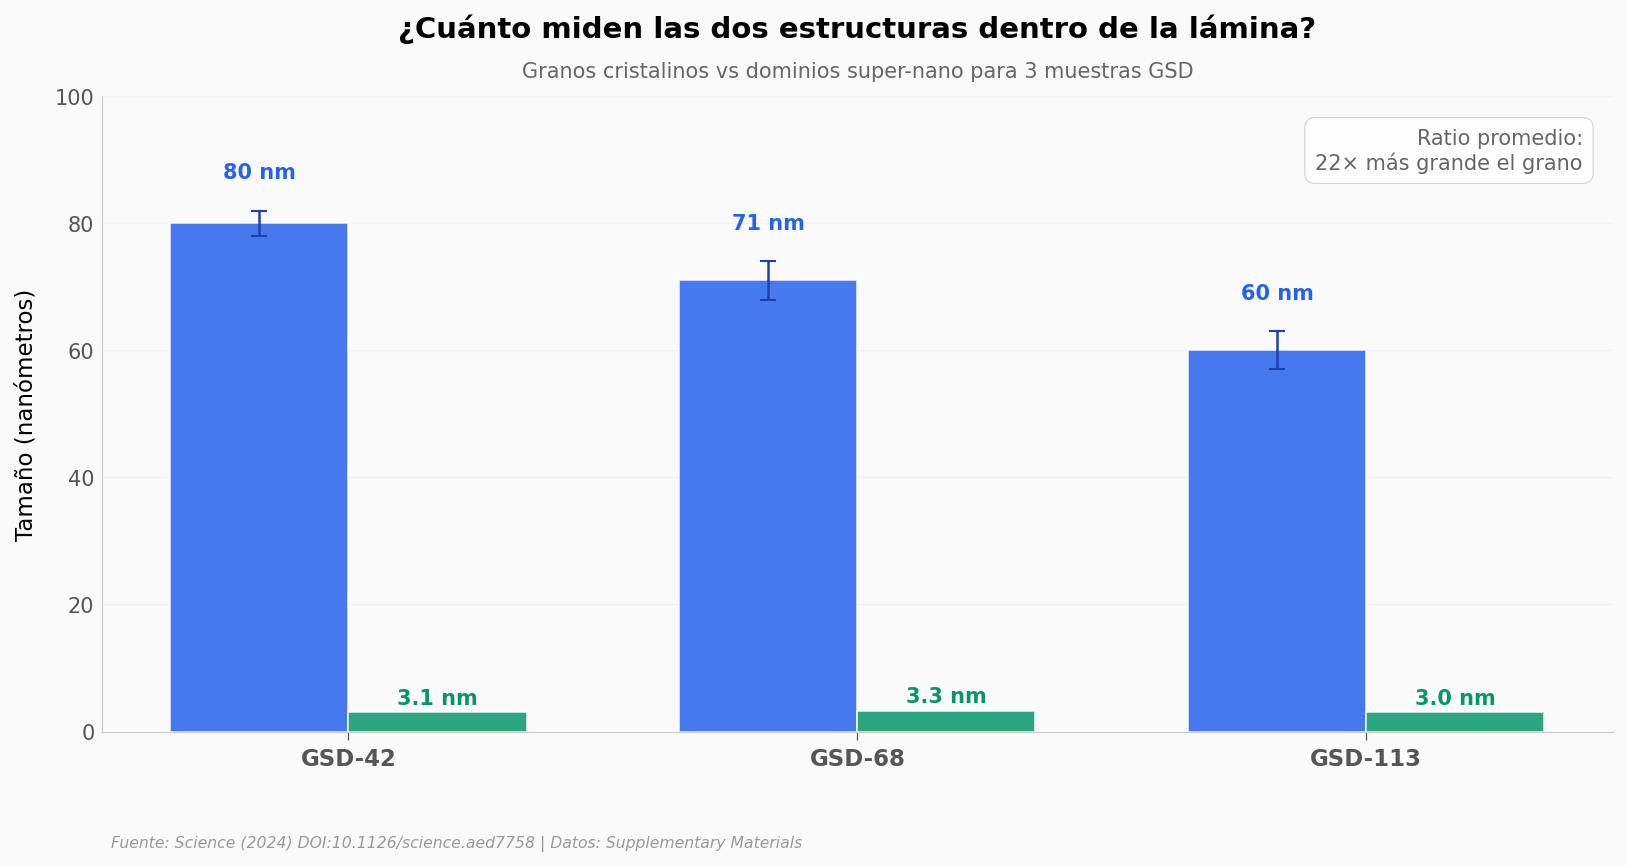

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x_pos = np.arange(len(tamanos))
ancho = 0.35

# Granos cristalinos (decenas de nm)
ax.bar(x_pos - ancho/2, tamanos['grain_size_nm'],
       yerr=tamanos['grain_size_err_nm'], width=ancho,
       color=COLOR_GSD, alpha=0.85, edgecolor='white', linewidth=0.8,
       capsize=4, error_kw={'lw': 1.2, 'ecolor': '#1e40af'},
       label='Grano cristalino', zorder=5)

# Dominios super-nano (~3 nm)
ax.bar(x_pos + ancho/2, tamanos['domain_size_nm'], width=ancho,
       color=COLOR_DOMAIN, alpha=0.85, edgecolor='white', linewidth=0.8,
       label='Dominio super-nano', zorder=5)

# Anotar valores encima de cada barra
for i, row in tamanos.iterrows():
    ax.text(i - ancho/2, row['grain_size_nm'] + row['grain_size_err_nm'] + 5,
            f"{int(row['grain_size_nm'])} nm",
            ha='center', fontsize=10, fontweight='bold', color=COLOR_GSD)
    ax.text(i + ancho/2, row['domain_size_nm'] + 1.2,
            f"{row['domain_size_nm']:.1f} nm",
            ha='center', fontsize=10, fontweight='bold', color=COLOR_DOMAIN)

ax.set_xticks(x_pos)
ax.set_xticklabels(tamanos['muestra'], fontsize=11, fontweight='bold')
ax.set_ylabel('Tamaño (nanómetros)', fontsize=11)
ax.set_title('¿Cuánto miden las dos estructuras dentro de la lámina?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Granos cristalinos vs dominios super-nano para 3 muestras GSD',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación del ratio
ratio_medio = (tamanos['grain_size_nm'] / tamanos['domain_size_nm']).mean()
ax.text(0.98, 0.95, f'Ratio promedio:\n{ratio_medio:.0f}× más grande el grano',
        transform=ax.transAxes, fontsize=10, color='#666666',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

ax.set_ylim(0, 100)
ax.grid(True, axis='y', alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dos_escalas.png', dpi=200, bbox_inches='tight')
plt.show()

Dos escalas conviven en la misma lámina, y son **independientes** entre sí. El grano va bajando de 80 a 60 nanómetros conforme cambia la composición. El dominio se queda clavado en torno a 3 nm en las tres muestras. La razón entre uno y otro es de unas 22 veces — es como si dentro de cada cristal hubiera islas mucho más pequeñas con su propia organización.

Esa coexistencia es lo que el paper apunta como mecanismo: los granos pequeños suben la resistencia, y los dominios bloquean el reordenamiento térmico que normalmente arruina los nanocristales con el tiempo.

## ¿Qué cambia entre las muestras?

La diferencia entre GSD-42, GSD-68 y GSD-113 está en la cantidad de aditivo orgánico (gelatina + HEC + MBI) que se añade al baño de electrodeposición. Veamos qué pasa cuando subimos esa concentración.

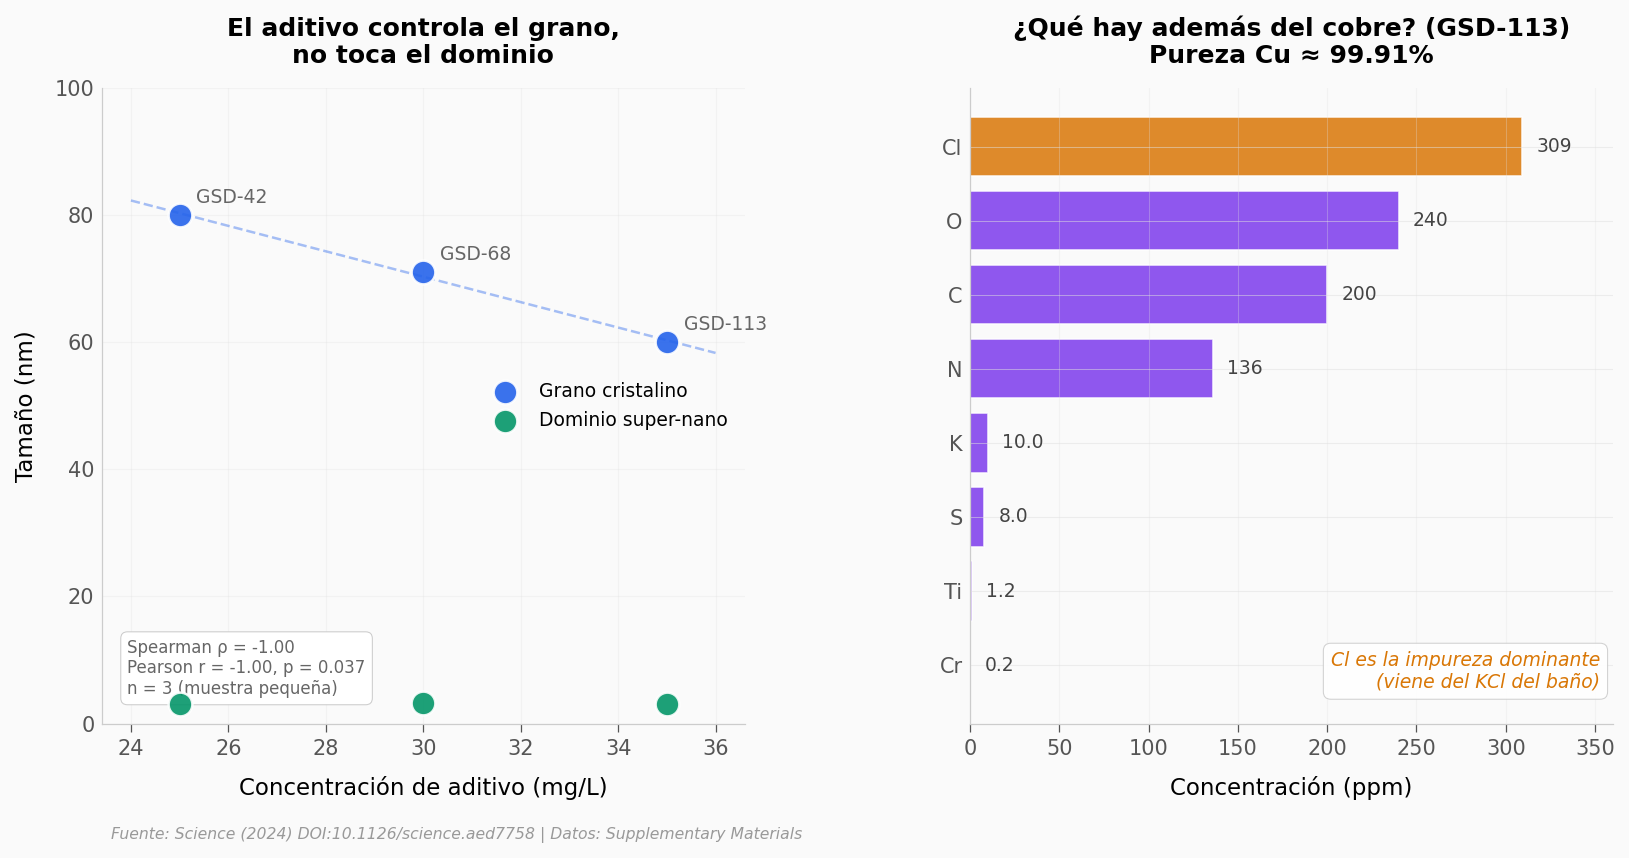

Total impurezas medidas: 904.5 ppm — pureza Cu ≈ 99.910%
Cl representa el 34.2% de las impurezas


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'wspace': 0.35})

# ── Subplot izquierdo: correlación aditivo vs grain size ──
x = tamanos['concentracion_aditivo_mg_L'].values
y_grain = tamanos['grain_size_nm'].values
y_domain = tamanos['domain_size_nm'].values

# Calcular correlación de Spearman (más conservador con n=3)
r_sp, p_sp = stats.spearmanr(x, y_grain)
# Pearson para reportar (paper lo usa)
r_pe, p_pe = stats.pearsonr(x, y_grain)

# Ajuste lineal solo para visualizar la tendencia
slope, intercept = np.polyfit(x, y_grain, 1)
x_fit = np.linspace(x.min() - 1, x.max() + 1, 50)
ax1.plot(x_fit, slope * x_fit + intercept, '--', color=COLOR_GSD, alpha=0.4, linewidth=1.2)

ax1.scatter(x, y_grain, color=COLOR_GSD, s=130, alpha=0.9,
            edgecolors='white', linewidths=1.2, zorder=5, label='Grano cristalino')
ax1.scatter(x, y_domain, color=COLOR_DOMAIN, s=130, alpha=0.9,
            edgecolors='white', linewidths=1.2, zorder=5, label='Dominio super-nano')

# Etiquetar cada punto con el nombre de la muestra
for i, row in tamanos.iterrows():
    ax1.annotate(row['muestra'],
                 xy=(row['concentracion_aditivo_mg_L'], row['grain_size_nm']),
                 xytext=(8, 6), textcoords='offset points',
                 fontsize=9, color='#666666')

ax1.set_xlabel('Concentración de aditivo (mg/L)', fontsize=11)
ax1.set_ylabel('Tamaño (nm)', fontsize=11)
ax1.set_title('El aditivo controla el grano,\nno toca el dominio',
              fontsize=12, fontweight='bold', pad=12)
ax1.legend(fontsize=9, loc='center right', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Caja con estadística (n=3 — reportamos ambas correlaciones honestamente)
ax1.text(0.04, 0.04,
         f'Spearman ρ = {r_sp:.2f}\nPearson r = {r_pe:.2f}, p = {p_pe:.3f}\nn = 3 (muestra pequeña)',
         transform=ax1.transAxes, fontsize=8, color='#666666',
         va='bottom', ha='left',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC'))

# ── Subplot derecho: composición química GSD-113 ──
comp_sorted = composicion.sort_values('promedio_ppm', ascending=True)
colores_barras = [COLOR_REF if e == 'Cl' else '#7C3AED' for e in comp_sorted['elemento']]

ax2.barh(comp_sorted['elemento'], comp_sorted['promedio_ppm'],
         color=colores_barras, alpha=0.85, edgecolor='white', linewidth=0.8)

# Anotar valores
for i, (elem, ppm) in enumerate(zip(comp_sorted['elemento'], comp_sorted['promedio_ppm'])):
    if ppm > 50:
        ax2.text(ppm + 8, i, f'{ppm:.0f}', va='center', fontsize=9, color='#444444')
    else:
        ax2.text(ppm + 8, i, f'{ppm:.1f}', va='center', fontsize=9, color='#444444')

total = composicion['promedio_ppm'].sum()
pureza = 100 - (total / 10000)

ax2.set_xlabel('Concentración (ppm)', fontsize=11)
ax2.set_title(f'¿Qué hay además del cobre? (GSD-113)\nPureza Cu ≈ {pureza:.2f}%',
              fontsize=12, fontweight='bold', pad=12)
ax2.text(0.98, 0.05, 'Cl es la impureza dominante\n(viene del KCl del baño)',
         transform=ax2.transAxes, fontsize=9, color=COLOR_REF,
         ha='right', va='bottom', style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))
ax2.grid(True, axis='x', alpha=0.3)
ax2.set_xlim(0, 360)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/aditivo_y_composicion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Total impurezas medidas: {total:.1f} ppm — pureza Cu ≈ {pureza:.3f}%')
print(f'Cl representa el {composicion[composicion["elemento"]=="Cl"]["promedio_ppm"].iloc[0]/total*100:.1f}% de las impurezas')

## ¿Por cuánto tiempo aguanta esa estructura?

Una cosa es fabricar nanocristales fuertes. Otra es que sigan siendo nanocristales después de un tiempo a temperatura ambiente — los granos chiquitos tienden a fusionarse con los vecinos, perdiendo dureza. El paper midió la microdureza durante **720 horas (un mes)** comparando GSD-113 con una lámina nanogranulada convencional (NG).

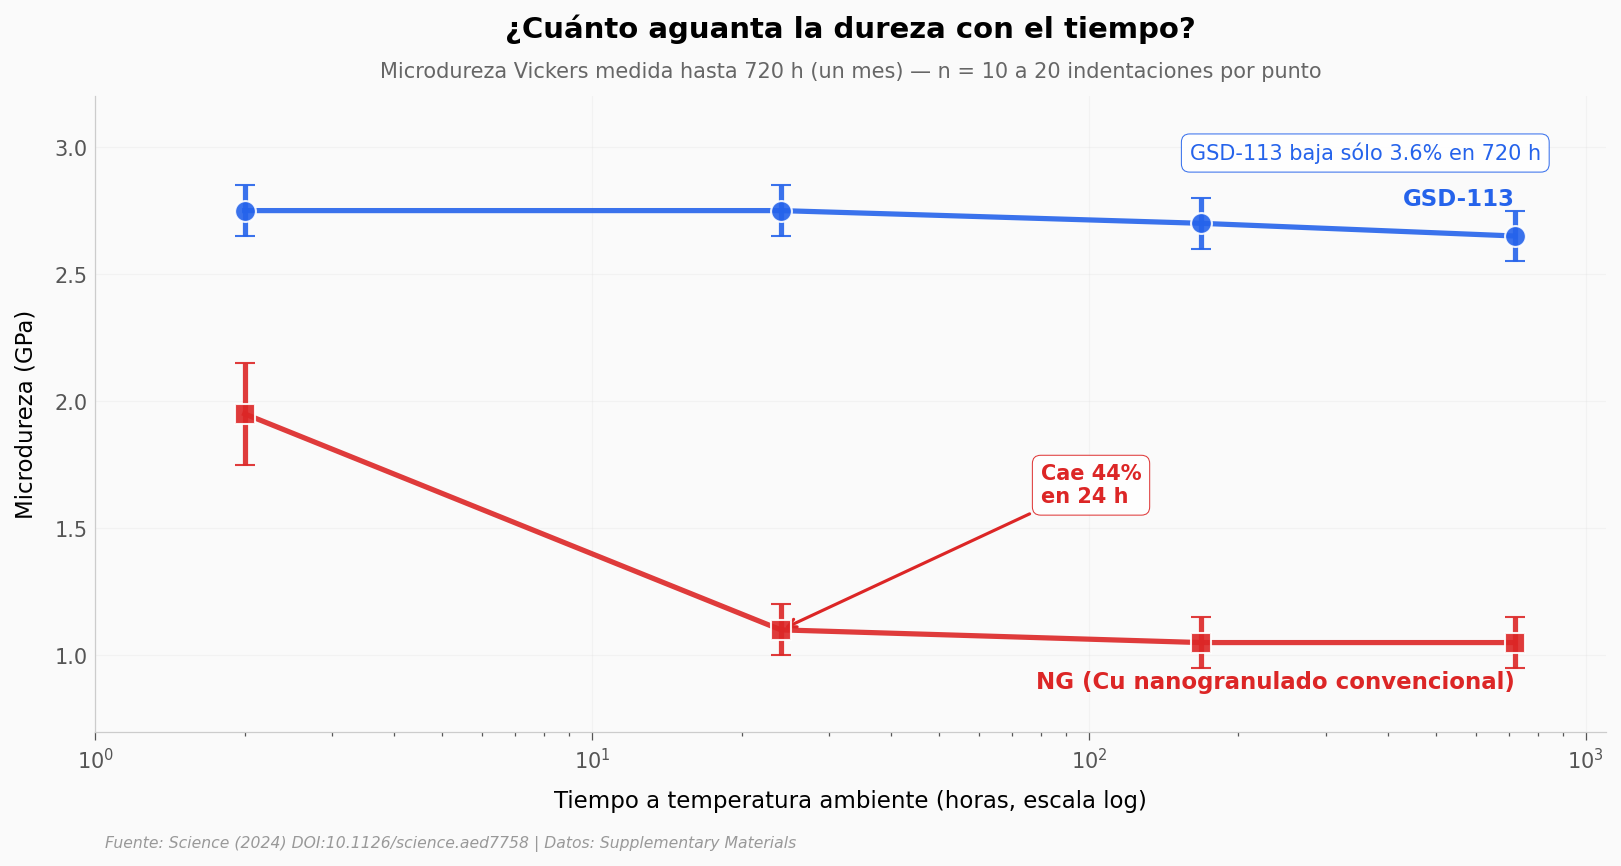

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar por muestra
gsd = estabilidad[estabilidad['muestra'] == 'GSD-113'].sort_values('tiempo_horas')
ng = estabilidad[estabilidad['muestra'] == 'NG'].sort_values('tiempo_horas')

# GSD-113
ax.errorbar(gsd['tiempo_horas'], gsd['hardness_gpa'],
            yerr=gsd['hardness_err_gpa'],
            color=COLOR_GSD, marker='o', markersize=10, linewidth=2.5,
            capsize=5, capthick=1.5, alpha=0.9, zorder=6,
            markeredgecolor='white', markeredgewidth=1)

# NG
ax.errorbar(ng['tiempo_horas'], ng['hardness_gpa'],
            yerr=ng['hardness_err_gpa'],
            color=COLOR_NG, marker='s', markersize=10, linewidth=2.5,
            capsize=5, capthick=1.5, alpha=0.9, zorder=6,
            markeredgecolor='white', markeredgewidth=1)

# Inline labels (no legend box)
ax.text(720, gsd['hardness_gpa'].iloc[-1] + 0.12, 'GSD-113',
        fontsize=11, fontweight='bold', color=COLOR_GSD, ha='right')
ax.text(720, ng['hardness_gpa'].iloc[-1] - 0.18, 'NG (Cu nanogranulado convencional)',
        fontsize=11, fontweight='bold', color=COLOR_NG, ha='right')

# Anotar valor inicial vs final NG
caida_ng_pct = (ng['hardness_gpa'].iloc[0] - ng['hardness_gpa'].iloc[1]) / ng['hardness_gpa'].iloc[0] * 100
ax.annotate(f'Cae {caida_ng_pct:.0f}%\nen 24 h',
            xy=(24, 1.10), xytext=(80, 1.6),
            fontsize=10, fontweight='bold', color=COLOR_NG,
            arrowprops=dict(arrowstyle='->', color=COLOR_NG, lw=1.5),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=COLOR_NG, alpha=0.9))

# Anotar estabilidad GSD
delta_gsd_pct = (gsd['hardness_gpa'].iloc[0] - gsd['hardness_gpa'].iloc[-1]) / gsd['hardness_gpa'].iloc[0] * 100
ax.text(360, 2.95, f'GSD-113 baja sólo {delta_gsd_pct:.1f}% en 720 h',
        fontsize=10, color=COLOR_GSD, ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=COLOR_GSD, alpha=0.9))

ax.set_xscale('log')
ax.set_xlabel('Tiempo a temperatura ambiente (horas, escala log)', fontsize=11)
ax.set_ylabel('Microdureza (GPa)', fontsize=11)
ax.set_title('¿Cuánto aguanta la dureza con el tiempo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Microdureza Vickers medida hasta 720 h (un mes) — n = 10 a 20 indentaciones por punto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_ylim(0.7, 3.2)
ax.set_xlim(1, 1100)
ax.grid(True, alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estabilidad_termica.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan grande es la diferencia al final del mes?

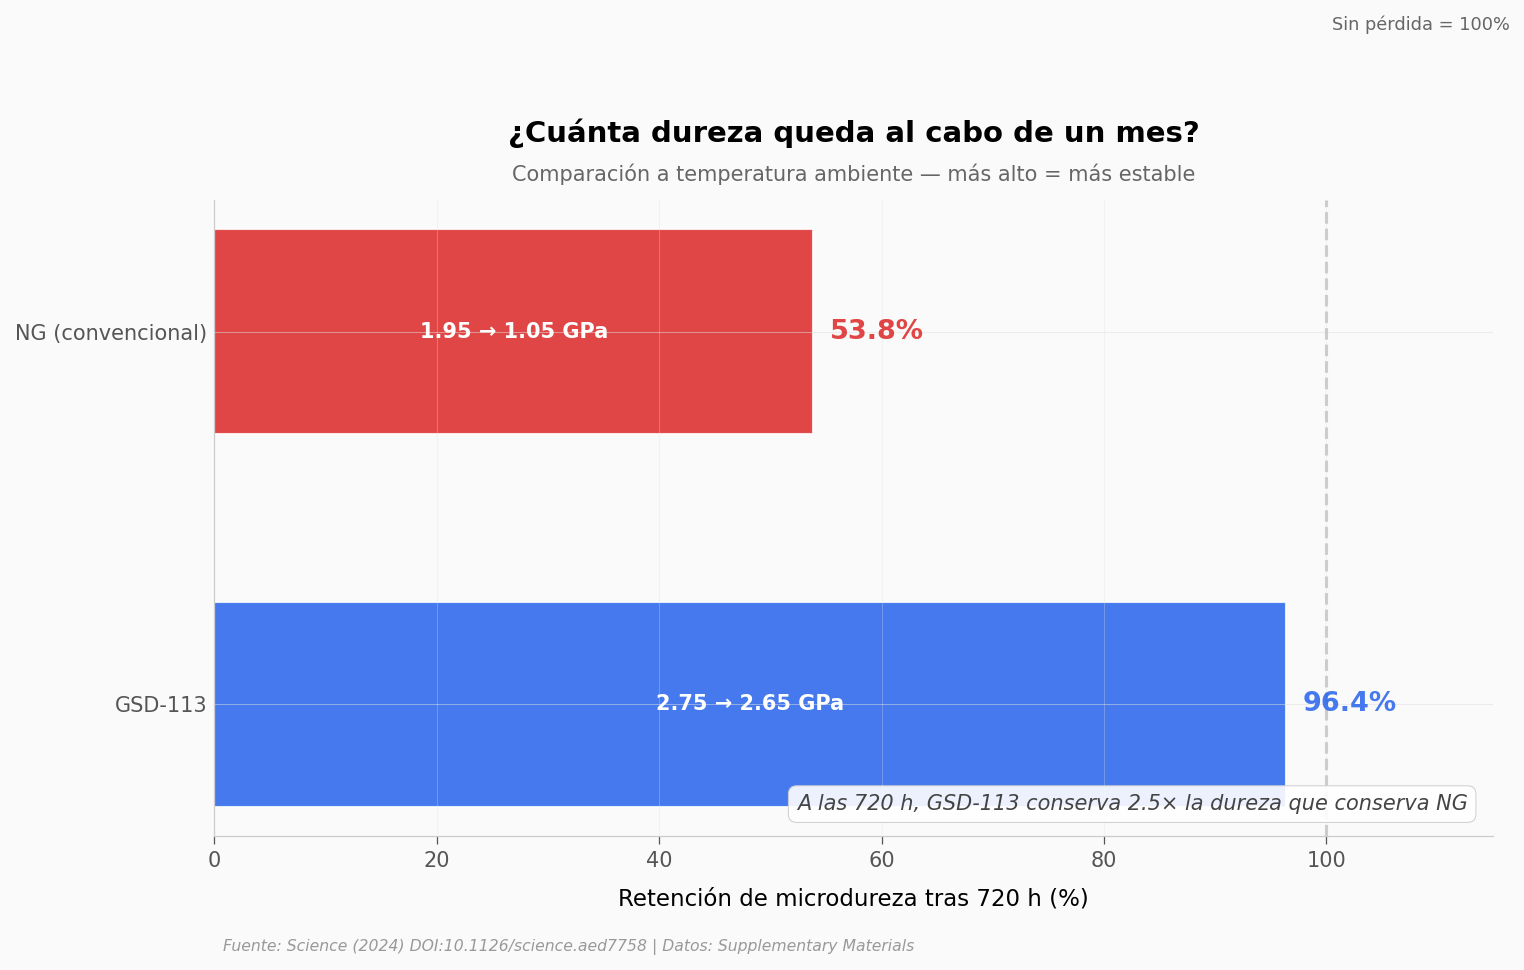

GSD-113 conserva 96.4% de la dureza tras 720 h
NG cae a 53.8% de su dureza inicial en el mismo lapso
Ratio de estabilidad GSD/NG a 720 h: 2.52×


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Calcular retención de dureza para cada muestra a 720 h
gsd_inicial = gsd['hardness_gpa'].iloc[0]
gsd_final = gsd['hardness_gpa'].iloc[-1]
gsd_retencion = gsd_final / gsd_inicial * 100

ng_inicial = ng['hardness_gpa'].iloc[0]
ng_final = ng['hardness_gpa'].iloc[-1]
ng_retencion = ng_final / ng_inicial * 100

# Barras horizontales
muestras_label = ['GSD-113', 'NG (convencional)']
retenciones = [gsd_retencion, ng_retencion]
colores = [COLOR_GSD, COLOR_NG]

bars = ax.barh(muestras_label, retenciones, color=colores, alpha=0.85,
               edgecolor='white', linewidth=1, height=0.55)

# Anotar valores dentro/junto a cada barra
for bar, ret, ini, fin in zip(bars, retenciones,
                                [gsd_inicial, ng_inicial],
                                [gsd_final, ng_final]):
    ax.text(ret + 1.5, bar.get_y() + bar.get_height()/2,
            f'{ret:.1f}%', va='center', fontsize=13, fontweight='bold',
            color=bar.get_facecolor())
    ax.text(ret/2, bar.get_y() + bar.get_height()/2,
            f'{ini:.2f} → {fin:.2f} GPa',
            va='center', ha='center', fontsize=10, color='white',
            fontweight='bold')

# Línea de referencia 100% (sin pérdida)
ax.axvline(100, color=COLOR_GRIS, linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(100.5, 1.85, 'Sin pérdida = 100%', fontsize=8.5, color='#666666', va='top')

ax.set_xlabel('Retención de microdureza tras 720 h (%)', fontsize=11)
ax.set_title('¿Cuánta dureza queda al cabo de un mes?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Comparación a temperatura ambiente — más alto = más estable',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(0, 115)
ax.grid(True, axis='x', alpha=0.3)

# Anotación interpretativa
ratio_estabilidad = gsd_final / ng_final
ax.text(0.98, 0.04,
        f'A las 720 h, GSD-113 conserva {ratio_estabilidad:.1f}× la dureza que conserva NG',
        transform=ax.transAxes, fontsize=10, color='#444444', ha='right',
        style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.9))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/retencion_hardness.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'GSD-113 conserva {gsd_retencion:.1f}% de la dureza tras 720 h')
print(f'NG cae a {ng_retencion:.1f}% de su dureza inicial en el mismo lapso')
print(f'Ratio de estabilidad GSD/NG a 720 h: {ratio_estabilidad:.2f}×')

## Lo que los datos del Supplementary soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El grano cristalino baja al aumentar el aditivo orgánico | ✅ | Spearman ρ = -1.0 (monotonía perfecta), Pearson r = -0.998 (p = 0.037). Con n = 3 la significancia estadística es marginal, pero la dirección es inequívoca |
| El dominio super-nano se mantiene en ~3 nm en las tres muestras | ✅ | Rango 3.0 - 3.3 nm; el aditivo controla el grano sin alterar el dominio |
| Los granos y los dominios viven a escalas independientes (ratio ~22×) | ✅ | Ratio promedio grano/dominio = 22.4 (calculado de Fig S4) |
| GSD-113 mantiene su dureza durante un mes | ✅ | Pierde 3.6% en 720 h (2.75 → 2.65 GPa) |
| NG (Cu nanogranulado convencional) pierde casi la mitad en 24 h | ✅ | Cae 43.6% (1.95 → 1.10 GPa) en sólo 24 h. A 720 h, GSD-113 conserva 2.52× la dureza de NG (2.65 vs 1.05 GPa); Cohen d formal no calculable — el SM accesible reporta media ± err por timepoint, no las 10-20 indentaciones crudas |
| La lámina logra ~900 MPa de resistencia y 90% IACS de conductividad | ⚠️ | Estos son los valores del *abstract*. El paper está detrás de paywall y las curvas tensión-deformación numéricas no están en el SM accesible — no podemos cruzarlos contra datos crudos aquí |
| Cl (309 ppm) es la impureza dominante de GSD-113 | ✅ | Confirmado en Tabla S1 de la composición GDMS — refleja el rol del KCl en el baño de electrodeposición |

> **Limitaciones honestas:**
> - **n = 3 muestras** para la correlación aditivo→grano. Spearman ρ = -1.0 es la máxima posible, pero estadísticamente es muestra pequeña.
> - **Estabilidad medida hasta 720 h** (un mes). NO se puede extrapolar a "permanente" ni a temperaturas elevadas.
> - **Datos del paper paywalled.** Las curvas tensión-deformación de Fig 3 y la conductividad por muestra no son cruzables contra datos crudos — los valores del headline (900 MPa, 90% IACS) provienen del abstract y del Editor's Summary.
> - **Comparación NG no es pareada.** GSD-113 vs NG son tipos de fabricación distintos, no réplicas del mismo material.

## Ahora tú

Algunas preguntas que se pueden explorar con estos mismos datos:

1. **¿Cómo se ve la diferencia GSD vs NG en escala lineal de tiempo?** Pista: cambia `ax.set_xscale('log')` por `ax.set_xscale('linear')` en la celda de estabilidad.
2. **¿Qué pasa si calculas el cociente dureza/tiempo (tasa de pérdida) por hora?** Pista: `df['delta'] = df['hardness_gpa'].diff() / df['tiempo_horas'].diff()`.
3. **¿Cómo se comparan las impurezas más bajas (Ti, Cr) con las dominantes en escala log?** Pista: `ax.set_xscale('log')` en la barra horizontal de composición.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Tasa de cambio de dureza por hora — ¿cuándo "se estabiliza" cada material?

for nombre, df in [('GSD-113', gsd), ('NG', ng)]:
    df = df.copy()
    df['delta_gpa_por_hora'] = df['hardness_gpa'].diff() / df['tiempo_horas'].diff()
    print(f'\n{nombre}:')
    print(df[['tiempo_horas', 'hardness_gpa', 'delta_gpa_por_hora']].to_string(index=False))


GSD-113:
 tiempo_horas  hardness_gpa  delta_gpa_por_hora
            2          2.75                 NaN
           24          2.75            0.000000
          168          2.70           -0.000347
          720          2.65           -0.000091

NG:
 tiempo_horas  hardness_gpa  delta_gpa_por_hora
            2          1.95                 NaN
           24          1.10           -0.038636
          168          1.05           -0.000347
          720          1.05            0.000000


---

## Fuentes

**Paper**: [Super-nano domains enable strength-conductivity synergy in copper foils](https://doi.org/10.1126/science.aed7758)  
*Science, 2026-04-16 · paywall*

**Supplementary Material**: [SM PDF (Tabla S1, Fig. S4, Fig. S7B)](https://www.science.org/doi/suppl/10.1126/science.aed7758/suppl_file/science.aed7758_sm.pdf)  
*Fuente directa de los datos del notebook (composición GDMS, tamaños grain/domain, estabilidad de hardness)*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook generado para [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com). Reproducible con los datos en este repo. Licencia: CC-BY 4.0 (notebook); los datos originales son del Supplementary Material del paper, sujetos a los términos de Science.*